In [13]:
import sys
import os

# Adds the project root directory to the Python search path
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.train_test_split import time_split
from models.arima_model import train_arima
from models.lstm_model import create_sequences, build_lstm, scale_data
from models.evaluation import mae, rmse,mape

In [14]:
df = pd.read_csv("../data/raw/TSLA.csv", parse_dates=["Date"])
df = df.set_index("Date")

df = df.asfreq("B")
df = df.ffill()

df.head()

,Close,High,Low,Open,Volume
Date,,,,,
2015-01-02,14.620667,14.883333,14.217333,14.858000,71466000.0
2015-01-05,14.006000,14.433333,13.810667,14.303333,80527500.0
2015-01-06,14.085333,14.280000,13.614000,14.004000,93928500.0
2015-01-07,14.063333,14.318667,13.985333,14.223333,44526000.0
2015-01-08,14.041333,14.253333,14.000667,14.187333,51637500.0


In [15]:
train, test = time_split(df["Close"])

print("Train size:", len(train))
print("Test size:", len(test))

Train size: 2608
Test size: 392


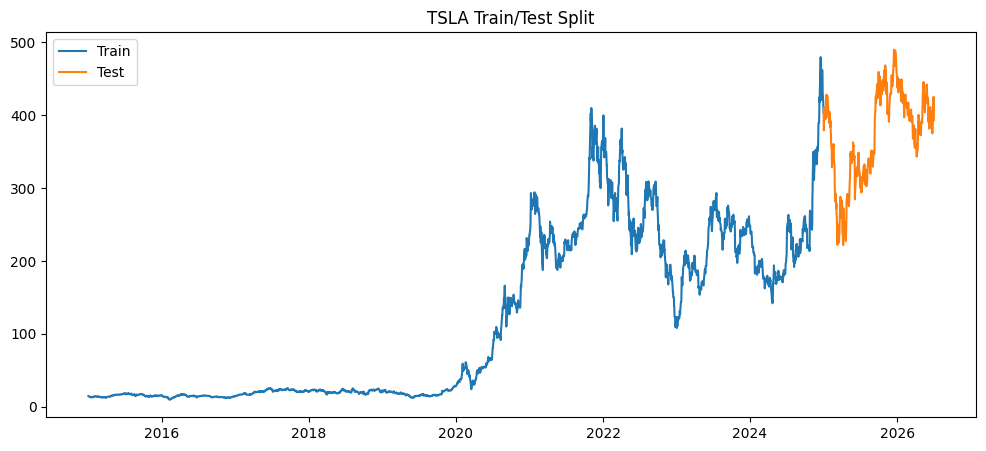

In [16]:
plt.figure(figsize=(12,5))
plt.plot(train, label="Train")
plt.plot(test, label="Test")
plt.title("TSLA Train/Test Split")
plt.legend()
plt.show()

In [17]:
print("Training ARIMA...")

arima_model = train_arima(train, order=(5,1,0))

arima_forecast = arima_model.forecast(steps=len(test))
arima_forecast = pd.Series(arima_forecast, index=test.index)

Training ARIMA...


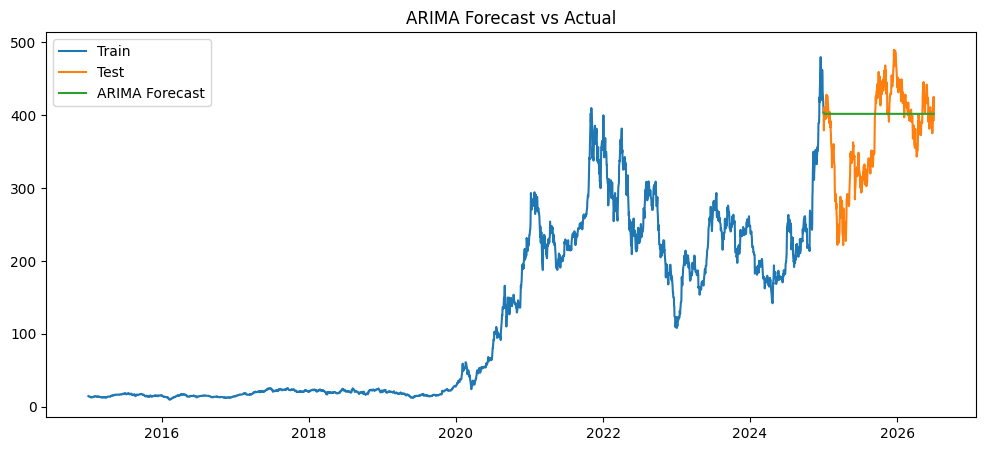

In [18]:
plt.figure(figsize=(12,5))
plt.plot(train, label="Train")
plt.plot(test, label="Test")
plt.plot(arima_forecast, label="ARIMA Forecast")
plt.legend()
plt.title("ARIMA Forecast vs Actual")
plt.show()

In [19]:
print("Preparing LSTM data...")

data = df["Close"].values
scaled, scaler = scale_data(data)

X, y = create_sequences(scaled, window=60)

split = int(len(X)*0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

model = build_lstm(60)

model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=1)

Preparing LSTM data...
Epoch 1/10


/home/welela/venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


74/74 ━━━━━━━━━━━━━━━━━━━━ 8s 45ms/step - loss: 0.0054
Epoch 2/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - loss: 7.9743e-04
Epoch 3/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - loss: 6.6515e-04
Epoch 4/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step - loss: 5.6041e-04
Epoch 5/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step - loss: 5.3251e-04
Epoch 6/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - loss: 4.5094e-04
Epoch 7/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - loss: 4.5159e-04
Epoch 8/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - loss: 4.1344e-04
Epoch 9/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - loss: 4.0064e-04
Epoch 10/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - loss: 3.7799e-04


In [20]:
pred = model.predict(X_test)

pred = scaler.inverse_transform(pred)
y_test_inv = scaler.inverse_transform(y_test.reshape(-1,1))

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step


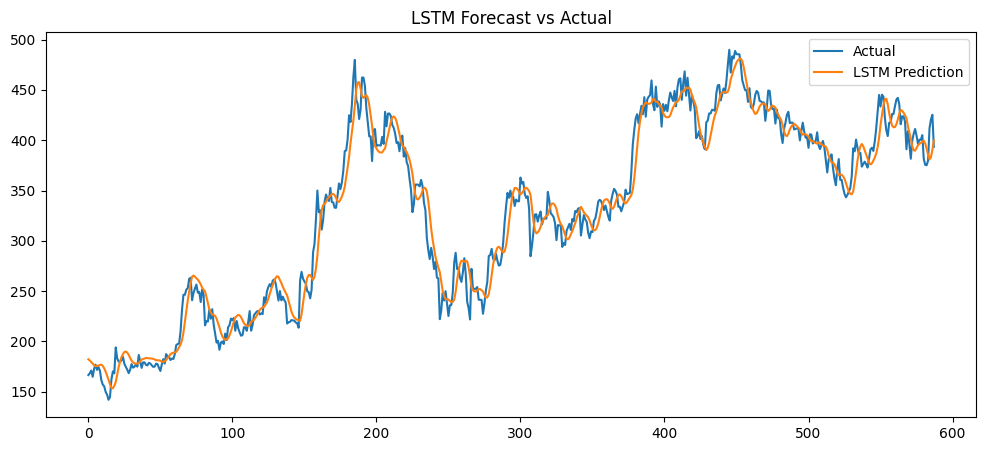

In [21]:
plt.figure(figsize=(12,5))
plt.plot(y_test_inv, label="Actual")
plt.plot(pred, label="LSTM Prediction")
plt.title("LSTM Forecast vs Actual")
plt.legend()
plt.show()

In [22]:
print("ARIMA Results")
arima_mae = mae(test.values, arima_forecast.values)
arima_rmse = rmse(test.values, arima_forecast.values)
from models.evaluation import mae, rmse, mape



print("MAE:", arima_mae)
print("RMSE:", arima_rmse)

print("\nLSTM Results")
lstm_mae = mae(y_test_inv, pred)
lstm_rmse = rmse(y_test_inv, pred)

print("MAE:", lstm_mae)
print("RMSE:", lstm_rmse)
print("ARIMA MAPE:", mape(test.values, arima_forecast.values))
print("LSTM MAPE:", mape(y_test_inv, pred))

ARIMA Results
MAE: 53.50007479530659
RMSE: 69.14463767244608

LSTM Results
MAE: 13.050932592275194
RMSE: 16.852724657358223
ARIMA MAPE: 16.842081516391378
LSTM MAPE: 4.211432098955234


In [23]:
results = pd.DataFrame({
    "Model": ["ARIMA", "LSTM"],
    "MAE": [arima_mae, lstm_mae],
    "RMSE": [arima_rmse, lstm_rmse]
})

results

,Model,MAE,RMSE
0,ARIMA,53.500075,69.144638
1,LSTM,13.050933,16.852725


## Conclusion

- ARIMA performs reasonably but struggles with nonlinear stock behavior.
- LSTM captures complex patterns better and achieves lower error.
- LSTM is more suitable for volatile assets like TSLA.